# Resample

The SCAMS data lies in swath coordinates and not on a grid. This means that the datapoints are lying on a strip along the track of the satellite. Every point has its own latitude and longitude but the points are not on rectangular grid. We want a grid with 25km pixels. For SCAMS to become a map we need. 
- A grid (EASE2 25km)
- One SCAMS-value per gridcell
- Normal mapformat so we can plot with with imshow
Pyresample will find the nearest SCAMS-point for every gridcell in the EASE2-system. 

In [8]:
import sys
import os
import string
import logging
import glob
import xarray as xr
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import datetime

import pyresample as pr
import math, cmath

In [89]:
#må lage en maske for arctic ice og antarctic ice

test_day = '1976'
def resample(date):
    
    indirectory = '/Users/jennybrun/Documents/Skole/DTU/Skole/Fall25/Remote Sensing/RemoteSensingProject/seaicemapping/SCAMS_tbfixed/'
    files = [f for f in os.listdir(indirectory) if date in f]
    lats_list = []
    lons_list = []
    sst_list = []
    t2m_list = []
    tbch1_list = [] #TBCH1
    sicconc_list = []


    for fname in files: 
        fullpath = os.path.join(indirectory, fname)
        ds = xr.open_dataset(fullpath)
        lats_list.append(ds['LAT'][:])
        lons_list.append(ds['LON'][:])
        sst_list.append(ds['sst'][:])
        t2m_list.append(ds['t2m'][:])
        tbch1_list.append(ds['TBCH1'][:])
        sicconc_list.append(ds['siconc'][:])
        #print(np.array(ds.variables))
        #print(np.asarray(ds.variables))
    lon = np.concatenate(lons_list)
    lat = np.concatenate(lats_list) #legg alle swaths oppå hverandre i tidsdimensjonen så vi får en lang swath shape = 109333, 13
    sst_e5 = np.concatenate(sst_list)
    t2m_e5 = np.concatenate(t2m_list)
    tbch1 = np.concatenate(tbch1_list)
    siconc_e5 = np.concatenate(sicconc_list)

    #dropper å bruke mid_swath fordi SCAMS har mye bedre footprint enn ESMR

    ocean = (siconc_e5 == 0) 
    warm_water = (sst_e5 > 278.0)
    ocean_mask = ocean & warm_water
    print(f'number of ocean points masked away: {np.sum(np.sum(ocean_mask))}')

    ice_waters = (sst_e5 <= 278.0)
    
    arctic = (lat > 40)
    north_pole = (lat < 90)
    antarctic = (lat < -40)
    south_pole = (lat > -90)

    arctic_ice = arctic & north_pole
    arctic_open_water = arctic & warm_water

    antarctic_ice = antarctic & south_pole
    antarctic_open_water = antarctic & warm_water


    tb_ice_arctic = tbch1[arctic_ice]
    sic_e5_arctic = siconc_e5[arctic_ice]
    tb_ice_antarctic = tbch1[antarctic_ice]
    sic_e5_antarctic = siconc_e5[antarctic_ice]
    #resample grids
    lon_n, lat_n = pr.utils.check_and_wrap(lon[arctic_ice], lat[arctic_ice])
    lon_s, lat_s = pr.utils.check_and_wrap(lon[antarctic_ice], lat[antarctic_ice])

    arctic_def = pr.geometry.SwathDefinition(lons=lon_n, lats=lat_n)
    antarctic_def = pr.geometry.SwathDefinition(lons=lon_s, lats=lat_s)

    #print(f'number of points in ice infested waters used for computation {np.sum(np.sum(arctic_ice)) + np.sum(np.sum(antarctic_ice))}')

    #EASE2-grid for north and south pole
    area_def_north_ease = pr.utils.parse_area_file('./areas_ease1.cfg', 'ease_nh')[0]
    area_def_south_ease = pr.utils.parse_area_file('./areas_ease1.cfg', 'ease_sh')[0]
    n_tb = pr.kd_tree.resample_nearest(
            arctic_def, #arctic mask
            tb_ice_arctic, #brightness temperatures from the arctic
            area_def_north_ease,
            radius_of_influence=50000, #hvor langt pyresample får lov til å "strekke seg for å finne et swath punkt"
            fill_value=None)
    
    s_tb = pr.kd_tree.resample_nearest(
            antarctic_def, 
            tb_ice_antarctic,
            area_def_south_ease,
            radius_of_influence=50000,
            fill_value=None
    )
    plt.imshow(n_tb,vmin=100,vmax=300)
    plt.colorbar()
    plt.show()

    
    plt.imshow(s_tb,vmin=100,vmax=300)
    plt.colorbar()
    plt.show()

    return 

number of ocean points masked away: 661768


/var/folders/k6/jwl4mb8n5jl7_0g1wtk01c_h0000gn/T/ipykernel_66306/3484770000.py:69: UserWarning: 'parse_area_file' has moved, import it with 'from pyresample import parse_area_file'
  area_def_north_ease = pr.utils.parse_area_file('./areas_ease1.cfg', 'ease_nh')[0]
/var/folders/k6/jwl4mb8n5jl7_0g1wtk01c_h0000gn/T/ipykernel_66306/3484770000.py:70: UserWarning: 'parse_area_file' has moved, import it with 'from pyresample import parse_area_file'
  area_def_south_ease = pr.utils.parse_area_file('./areas_ease1.cfg', 'ease_sh')[0]
/opt/miniconda3/envs/ultralyd/lib/python3.10/site-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


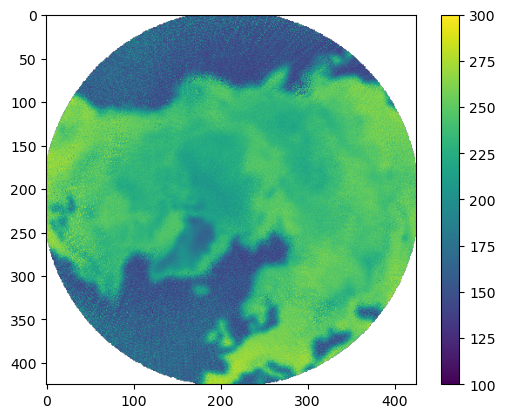

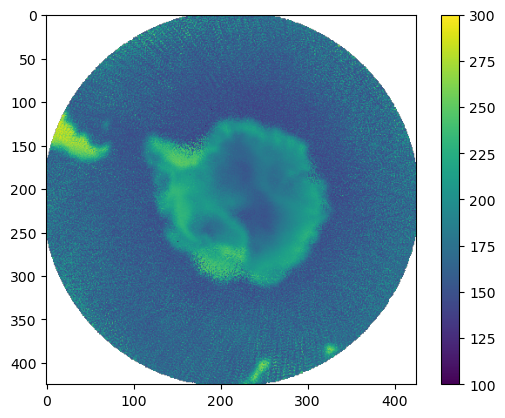

()


In [90]:
lat = resample(test_day)
print(np.shape(lat))